Aditya Mitra

11/14/2025

ENGR118_F25_L7

## Problem 1

**Evaluate a definite integral analytically, then approximate using trapezoid rule (different segment counts) and Python’s quad**

In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [9]:
# Function to integrate
f = lambda x: 1 - np.exp(-x)

# Composite trapezoid rule
def trap(f, a, b, n):
    x = np.linspace(a, b, n+1)
    y = f(x)
    return (b - a)/n * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

In [10]:
I2 = trap(f, 0, 4, 2)
I4 = trap(f, 0, 4, 4)

In [11]:
I100 = trap(f, 0, 4, 100)

In [13]:
I_quad, _ = quad(lambda x: 1 - np.exp(-x), 0, 4)

print("Trapezoid n=2:", I2)
print("Trapezoid n=4:", I4)
print("Trapezoid n=100:", I100)
print("quad result:", I_quad)

Trapezoid n=2: 2.71101379463804
Trapezoid n=4: 2.9378403877797137
Trapezoid n=100: 3.018184751130886
quad result: 3.018315638888734


## Problem 2

**Solve a radioactive decay ODE using Euler’s method with different step sizes, plot concentration vs. time, and discuss accuracy of solutions**

In [14]:
def euler(k, c0, t_end, h):
    t = np.arange(0, t_end + h, h)
    c = np.zeros_like(t)
    c[0] = c0
    for i in range(1, len(t)):
        c[i] = c[i-1] + h * (-k * c[i-1])
    return t, c

In [19]:
k = 0.175
c0 = 75

# Compute solutions for different step sizes
t1, c1 = euler(k, c0, 10, 1.0)
t2, c2 = euler(k, c0, 10, 0.5)
t3, c3 = euler(k, c0, 10, 0.1)

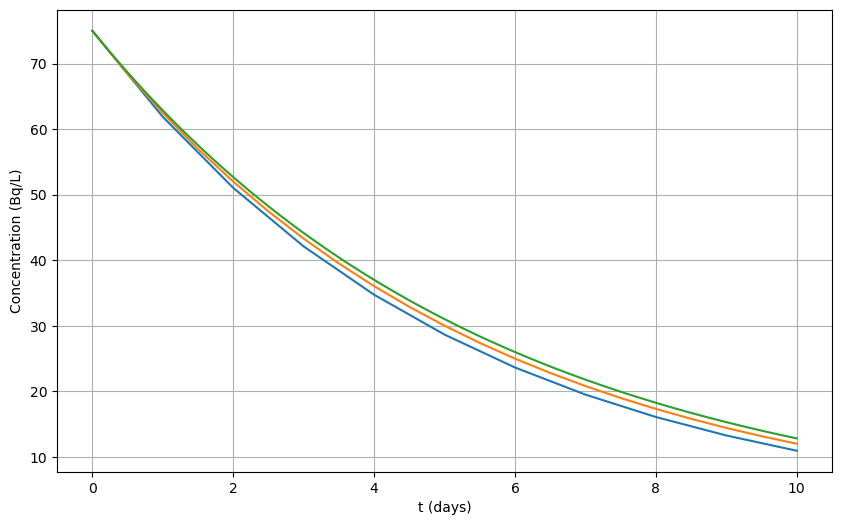

In [20]:
# Plotting
plt.figure(figsize=(10,6))
plt.plot(t1, c1, label='h = 1.0')
plt.plot(t2, c2, label='h = 0.5')
plt.plot(t3, c3, label='h = 0.1')
plt.xlabel('t (days)')
plt.ylabel('Concentration (Bq/L)')
plt.grid()
plt.show()